## Imports and Data Loading

In [8]:
# imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet


from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from data_cleaning import load_clean_data
from sklearn.linear_model import LinearRegression

In [9]:
# load data
df = load_clean_data("data/caml_satellite_matchup.csv")

rows pre-cleaning: 23570
rows removed due to no sensor match: 10091
rows removed due to impossible band values: 332
rows removed due to spatial overlap: 3967
rows post-cleaning: 9180


## Feature Importance using Random Forest Regressor

In [58]:
# drop target columns and columns that will likely lead to overfitting if included
drop_cols = ["log_abundance", "cyanobacteria_abundance", "latitude", "longitude", "sample_date", "satellite_date"]
X = df.drop(columns=drop_cols)
y = df["log_abundance"]

In [55]:
# fill missing values with -999
X = X.fillna(-999)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
# create random forest model
rf = RandomForestRegressor(n_estimators=500, random_state=42, max_features=None)
rf.fit(X_train, y_train)
print("R Squared:", rf.score(X_test, y_test))

R Squared: 0.40318702635744785


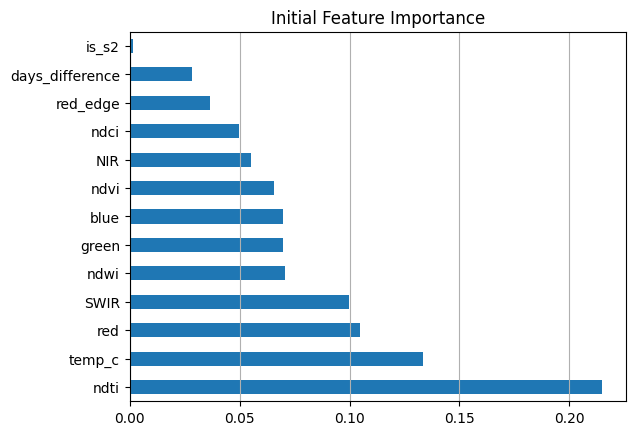

In [49]:
# plot feature importances 
feat_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_importances.nlargest(15).plot(kind='barh')
plt.title("Initial Feature Importance")
plt.grid(which="both", axis="x")
plt.show()

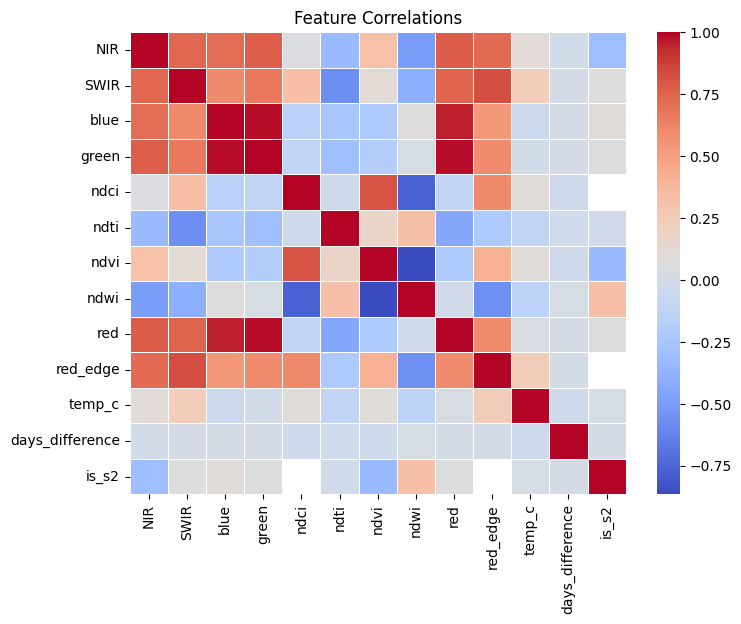

In [59]:
# get feature correlations
matrix = X.corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlations")
plt.show()

In [ ]:
drop = ["is_s2", "days_difference", "NIR", "ndwi"]
X = X.drop(columns=drop)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
rf = RandomForestRegressor(n_estimators=500, random_state=42, max_features=None)
rf.fit(X_train, y_train)
print("R Squared:", rf.score(X_test, y_test))

R Squared: 0.39644106034279347
